In [71]:
import numpy as np              # calcul numérique (tableaux, opérations mathématiques)
import pandas as pd             # manipulation de tables de données (DataFrames)
import matplotlib.pyplot as plt # tracé de graphiques
import seaborn as sns           # graphiques plus jolis, basés sur matplotlib

# Prétraitement des données
from sklearn.preprocessing import StandardScaler   # pour standardiser (z-score) les colonnes

# Réduction de dimension
from sklearn.decomposition import PCA               # Analyse en Composantes Principales (visualisation 2D)

# Algorithmes de clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

# Métriques pour évaluer la qualité des clusters
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

# Outils pour la CAH (dendrogramme, découpe de l'arbre)
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Style des graphiques (fond gris clair avec grille, plus lisible)
sns.set_style("whitegrid")

# Graine aléatoire fixe : garantit que si on relance le code, on obtient EXACTEMENT
# les mêmes résultats (K-means et GMM utilisent de l'aléatoire au départ)
RANDOM_STATE = 42

In [72]:
import os
# On regarde à l'intérieur du sous-dossier imbriqué
print(os.listdir("data/hhblock_dataset/hhblock_dataset"))

['block_0.csv', 'block_1.csv', 'block_10.csv', 'block_100.csv', 'block_101.csv', 'block_102.csv', 'block_103.csv', 'block_104.csv', 'block_105.csv', 'block_106.csv', 'block_107.csv', 'block_108.csv', 'block_109.csv', 'block_11.csv', 'block_110.csv', 'block_111.csv', 'block_12.csv', 'block_13.csv', 'block_14.csv', 'block_15.csv', 'block_16.csv', 'block_17.csv', 'block_18.csv', 'block_19.csv', 'block_2.csv', 'block_20.csv', 'block_21.csv', 'block_22.csv', 'block_23.csv', 'block_24.csv', 'block_25.csv', 'block_26.csv', 'block_27.csv', 'block_28.csv', 'block_29.csv', 'block_3.csv', 'block_30.csv', 'block_31.csv', 'block_32.csv', 'block_33.csv', 'block_34.csv', 'block_35.csv', 'block_36.csv', 'block_37.csv', 'block_38.csv', 'block_39.csv', 'block_4.csv', 'block_40.csv', 'block_41.csv', 'block_42.csv', 'block_43.csv', 'block_44.csv', 'block_45.csv', 'block_46.csv', 'block_47.csv', 'block_48.csv', 'block_49.csv', 'block_5.csv', 'block_50.csv', 'block_51.csv', 'block_52.csv', 'block_53.csv', '

In [73]:
df_test = pd.read_csv("data/hhblock_dataset/hhblock_dataset/block_0.csv")

print(df_test.shape)

print(df_test.columns.tolist())

df_test.head()

(25286, 50)
['LCLid', 'day', 'hh_0', 'hh_1', 'hh_2', 'hh_3', 'hh_4', 'hh_5', 'hh_6', 'hh_7', 'hh_8', 'hh_9', 'hh_10', 'hh_11', 'hh_12', 'hh_13', 'hh_14', 'hh_15', 'hh_16', 'hh_17', 'hh_18', 'hh_19', 'hh_20', 'hh_21', 'hh_22', 'hh_23', 'hh_24', 'hh_25', 'hh_26', 'hh_27', 'hh_28', 'hh_29', 'hh_30', 'hh_31', 'hh_32', 'hh_33', 'hh_34', 'hh_35', 'hh_36', 'hh_37', 'hh_38', 'hh_39', 'hh_40', 'hh_41', 'hh_42', 'hh_43', 'hh_44', 'hh_45', 'hh_46', 'hh_47']


,LCLid,day,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
0,MAC000002,2012-10-13,0.263,0.269,0.275,0.256,0.211,0.136,0.161,0.119,...,0.918,0.278,0.267,0.239,0.230,0.233,0.235,0.188,0.259,0.250
1,MAC000002,2012-10-14,0.262,0.166,0.226,0.088,0.126,0.082,0.123,0.083,...,1.075,0.956,0.821,0.745,0.712,0.511,0.231,0.210,0.278,0.159
2,MAC000002,2012-10-15,0.192,0.097,0.141,0.083,0.132,0.070,0.130,0.074,...,1.164,0.249,0.225,0.258,0.260,0.334,0.299,0.236,0.241,0.237
3,MAC000002,2012-10-16,0.237,0.237,0.193,0.118,0.098,0.107,0.094,0.109,...,0.966,0.172,0.192,0.228,0.203,0.211,0.188,0.213,0.157,0.202
4,MAC000002,2012-10-17,0.157,0.211,0.155,0.169,0.101,0.117,0.084,0.118,...,0.223,0.075,0.230,0.208,0.265,0.377,0.327,0.277,0.288,0.256


In [74]:
# Chemin vers le dossier contenant tous les blocks
HHBLOCK_DIR = "data/hhblock_dataset/hhblock_dataset"

# On liste tous les fichiers du dossier, et on garde seulement ceux qui finissent par ".csv"
# (au cas où il y aurait d'autres fichiers cachés dans le dossier)
block_files = [f for f in os.listdir(HHBLOCK_DIR) if f.endswith(".csv")]

# sorted() trie la liste par ordre alphabétique (pas indispensable, mais plus propre)
block_files = sorted(block_files)

print(f"{len(block_files)} fichiers block_*.csv trouvés")

# Liste vide qui va contenir chaque DataFrame (un par fichier block)
dfs = []

for f in block_files:
    # os.path.join construit le chemin complet : dossier + "/" + nom du fichier
    chemin_complet = os.path.join(HHBLOCK_DIR, f)
    
    # On charge le fichier et on l'ajoute à la liste
    df_block = pd.read_csv(chemin_complet)
    dfs.append(df_block)

# pd.concat empile tous les DataFrames de la liste les uns sous les autres
# ignore_index=True : on ne garde pas les anciens numéros de ligne, on repart de 0
df_hh = pd.concat(dfs, ignore_index=True)

# Vérification : nombre total de lignes et colonnes après empilement
print(df_hh.shape)
df_hh.head()

112 fichiers block_*.csv trouvés
(3469352, 50)


,LCLid,day,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
0,MAC000002,2012-10-13,0.263,0.269,0.275,0.256,0.211,0.136,0.161,0.119,...,0.918,0.278,0.267,0.239,0.230,0.233,0.235,0.188,0.259,0.250
1,MAC000002,2012-10-14,0.262,0.166,0.226,0.088,0.126,0.082,0.123,0.083,...,1.075,0.956,0.821,0.745,0.712,0.511,0.231,0.210,0.278,0.159
2,MAC000002,2012-10-15,0.192,0.097,0.141,0.083,0.132,0.070,0.130,0.074,...,1.164,0.249,0.225,0.258,0.260,0.334,0.299,0.236,0.241,0.237
3,MAC000002,2012-10-16,0.237,0.237,0.193,0.118,0.098,0.107,0.094,0.109,...,0.966,0.172,0.192,0.228,0.203,0.211,0.188,0.213,0.157,0.202
4,MAC000002,2012-10-17,0.157,0.211,0.155,0.169,0.101,0.117,0.084,0.118,...,0.223,0.075,0.230,0.208,0.265,0.377,0.327,0.277,0.288,0.256


In [75]:

df_hh["day"] = pd.to_datetime(df_hh["day"])

print(df_hh["day"].dtype)

print("Première date :", df_hh["day"].min())
print("Dernière date :", df_hh["day"].max())

datetime64[ns]
Première date : 2011-11-24 00:00:00
Dernière date : 2014-02-27 00:00:00


In [76]:
df_hh["year_month"] = df_hh["day"].dt.to_period("M")

jours_par_foyer_mois = df_hh.groupby(["LCLid", "year_month"])["day"].nunique()

mois_a_tester = ["2011-11", "2011-12", "2012-01", "2012-02", "2012-03", "2012-04", "2012-05", "2012-06", "2012-07", "2012-08", "2012-09", "2012-10", "2012-11", "2012-12", "2013-01", "2013-02", "2013-03", "2013-04", "2013-05", "2013-06", "2013-07", "2013-08", "2013-09", "2013-10", "2013-11", "2013-12", "2014-01", "2014-02"]

for mois in mois_a_tester:
    
    nb_jours_attendus = pd.Period(mois).days_in_month
    
    
    sous_ensemble = jours_par_foyer_mois[jours_par_foyer_mois.index.get_level_values("year_month") == mois]
    
    nb_foyers_complets = (sous_ensemble == nb_jours_attendus).sum()
    nb_foyers_total = sous_ensemble.shape[0]
    
    print(f"{mois} : {nb_foyers_complets}/{nb_foyers_total} foyers complets "
          f"({100*nb_foyers_complets/nb_foyers_total:.1f}%)")

2011-11 : 0/63 foyers complets (0.0%)
2011-12 : 72/411 foyers complets (17.5%)
2012-01 : 356/567 foyers complets (62.8%)
2012-02 : 491/828 foyers complets (59.3%)
2012-03 : 755/1231 foyers complets (61.3%)
2012-04 : 1013/2035 foyers complets (49.8%)
2012-05 : 1487/3617 foyers complets (41.1%)
2012-06 : 2229/4201 foyers complets (53.1%)
2012-07 : 3526/4749 foyers complets (74.2%)
2012-08 : 4080/4764 foyers complets (85.6%)
2012-09 : 4300/5007 foyers complets (85.9%)
2012-10 : 4062/5521 foyers complets (73.6%)
2012-11 : 4864/5534 foyers complets (87.9%)
2012-12 : 4319/5537 foyers complets (78.0%)
2013-01 : 4708/5515 foyers complets (85.4%)
2013-02 : 4701/5490 foyers complets (85.6%)
2013-03 : 4672/5442 foyers complets (85.9%)
2013-04 : 4520/5409 foyers complets (83.6%)
2013-05 : 4667/5380 foyers complets (86.7%)
2013-06 : 4748/5357 foyers complets (88.6%)
2013-07 : 4338/5341 foyers complets (81.2%)
2013-08 : 4564/5294 foyers complets (86.2%)
2013-09 : 4735/5254 foyers complets (90.1%)
20

## Justification du choix du mois — Janvier 2013

Janvier 2013 fait partie des mois les plus complets du dataset (**85.4%** des foyers avec leurs 31 jours renseignés, contre 78% à 90.1% selon les mois testés). C'est un mois hivernal froid (température min. moyenne : 2.6°C), ce qui rend le signal "chauffage électrique" bien visible dans les courbes de charge. Il est situé en 2013, année où le tarif dynamique dToU était actif, permettant un croisement pertinent profils × tarif. Un seul jour férié tombe en janvier (1er janvier), facilement isolé du calcul de la journée moyenne. Février 2013 (météo et complétude comparables) est retenu comme second mois pour le test de stabilité des clusters.

In [77]:
MOIS_CHOISI = "2013-01"  

periode = pd.Period(MOIS_CHOISI)
PERIOD_START = periode.start_time  
PERIOD_END = periode.end_time     

n_jours_attendus = periode.days_in_month
print(f"Mois choisi : {MOIS_CHOISI} — {n_jours_attendus} jours attendus")

df_periode = df_hh[(df_hh["day"] >= PERIOD_START) & (df_hh["day"] <= PERIOD_END)].copy()

print(f"Lignes dans la période : {df_periode.shape[0]}")


Mois choisi : 2013-01 — 31 jours attendus
Lignes dans la période : 169565


In [78]:
df_periode.head()

,LCLid,day,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,...,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47,year_month
76,MAC000002,2013-01-01,0.219,0.241,0.191,0.235,0.182,0.229,0.194,0.201,...,0.209,0.886,0.573,0.250,0.292,0.231,0.281,0.253,0.258,2013-01
77,MAC000002,2013-01-02,0.253,0.211,0.347,0.280,0.261,0.229,0.258,0.125,...,0.215,0.640,0.588,0.254,0.236,0.269,0.268,0.245,0.255,2013-01
78,MAC000002,2013-01-03,0.196,0.239,0.235,0.195,0.239,0.201,0.206,0.133,...,0.243,0.265,1.098,0.256,0.218,0.247,0.276,0.238,0.286,2013-01
79,MAC000002,2013-01-04,0.257,0.263,0.296,0.284,0.241,0.246,0.244,0.254,...,0.242,0.662,0.601,0.226,0.228,0.227,0.176,0.252,0.198,2013-01
80,MAC000002,2013-01-05,0.195,0.208,0.171,0.226,0.188,0.207,0.210,0.114,...,0.228,0.184,0.222,0.289,0.232,0.285,0.251,0.270,0.282,2013-01


In [79]:

compte_jours_par_foyer = df_periode.groupby("LCLid")["day"].nunique()

foyers_complets = compte_jours_par_foyer[compte_jours_par_foyer == n_jours_attendus].index

foyers_incomplets = compte_jours_par_foyer[compte_jours_par_foyer != n_jours_attendus].index

print(f"Foyers présents sur la période : {len(compte_jours_par_foyer)}")
print(f"Foyers COMPLETS ({n_jours_attendus}/{n_jours_attendus} jours) : {len(foyers_complets)}")
print(f"Foyers EXCLUS (incomplets) : {len(foyers_incomplets)} "
      f"({100*len(foyers_incomplets)/len(compte_jours_par_foyer):.1f}% du total)")

df_complete = df_periode[df_periode["LCLid"].isin(foyers_complets)].copy()

df_complete = df_complete.sort_values(["LCLid", "day"]).reset_index(drop=True)

print(f"\nDataset final : {df_complete['LCLid'].nunique()} foyers, {df_complete.shape[0]} lignes")

Foyers présents sur la période : 5515
Foyers COMPLETS (31/31 jours) : 4708
Foyers EXCLUS (incomplets) : 807 (14.6% du total)

Dataset final : 4708 foyers, 145948 lignes


In [80]:
hh_cols = [f"hh_{i}" for i in range(48)]

print("Valeurs manquantes (NaN) :", df_complete[hh_cols].isna().sum().sum())

print("Valeurs négatives :", (df_complete[hh_cols] < 0).sum().sum())

Valeurs manquantes (NaN) : 0
Valeurs négatives : 0


In [81]:
hh_cols = [f"hh_{i}" for i in range(48)]

mean_curves = df_complete.groupby("LCLid")[hh_cols].mean()

print(mean_curves.shape)

mean_curves.head()

(4708, 48)


,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,hh_9,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
LCLid,,,,,,,,,,,,,,,,,,,,,
MAC000002,0.230097,0.239194,0.233871,0.222677,0.201871,0.176774,0.146806,0.121968,0.113323,0.109161,...,0.329516,0.392484,0.886000,0.390516,0.293258,0.326387,0.339839,0.354000,0.297935,0.269419
MAC000003,2.633161,2.574387,2.490645,2.035226,1.926742,1.908548,1.969677,1.895677,2.033581,1.846355,...,0.200258,0.164226,0.184226,0.184000,0.176871,0.159258,0.164065,0.192129,0.182581,0.143516
MAC000004,0.027742,0.044258,0.041581,0.018290,0.037581,0.049032,0.034194,0.050484,0.017581,0.022194,...,0.035032,0.041226,0.048419,0.032968,0.024677,0.049161,0.050032,0.042323,0.023194,0.041774
MAC000005,0.049516,0.036774,0.031710,0.030194,0.030355,0.030516,0.030516,0.030290,0.030355,0.029806,...,0.218000,0.192290,0.153903,0.131968,0.149000,0.188161,0.201677,0.189032,0.125968,0.085677
MAC000006,0.033065,0.029903,0.025581,0.021000,0.021323,0.021613,0.020032,0.021839,0.020548,0.022355,...,0.098516,0.095613,0.088484,0.094290,0.073839,0.056839,0.050677,0.055161,0.038742,0.045323


In [82]:
X = mean_curves.values

row_mean = X.mean(axis=1, keepdims=True)
row_std = X.std(axis=1, keepdims=True)

X_row_scaled = (X - row_mean) / row_std

print("Moyenne du foyer 0 (doit être ≈0):", X_row_scaled[0].mean())
print("Écart-type du foyer 0 (doit être ≈1):", X_row_scaled[0].std())

Moyenne du foyer 0 (doit être ≈0): 1.0408340855860843e-16
Écart-type du foyer 0 (doit être ≈1): 1.0


C:\Users\douah\AppData\Local\Temp\ipykernel_10660\636408942.py:6: RuntimeWarning: invalid value encountered in divide
  X_row_scaled = (X - row_mean) / row_std


On retient l'**option B** (normalisation par ligne) car le sujet demande de comparer des *formes* de courbes, pas des volumes de consommation : cette normalisation place deux foyers ayant le même profil horaire au même endroit dans l'espace, indépendamment de leur consommation totale (petit studio vs grande maison) contrairement a l'**option A** qui garde une part du volume.

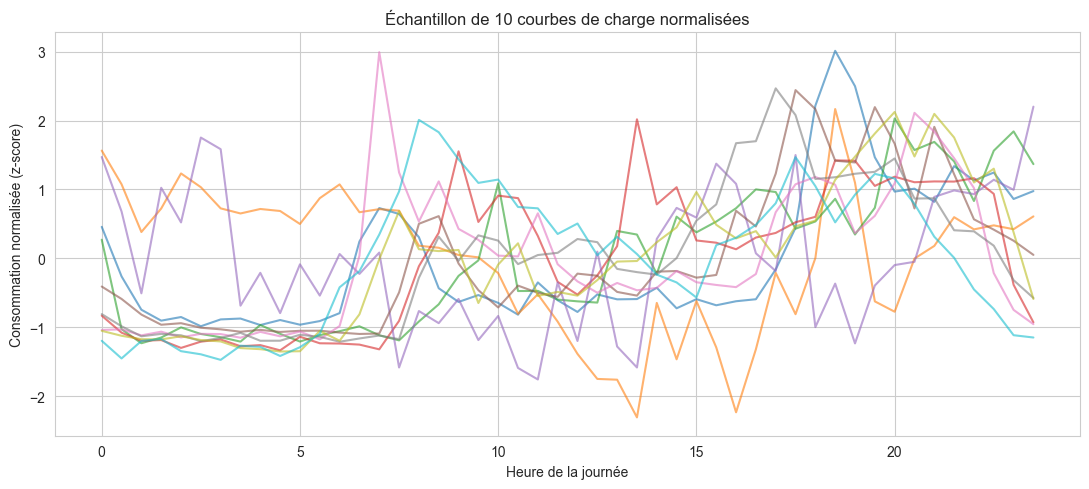

In [83]:
plt.figure(figsize=(11, 5))

# np.arange(48)/2 : convertit les 48 indices (0 à 47) en heures (0.0 à 23.5)
heures = np.arange(48) / 2

# On prend 10 foyers au hasard dans X_row_scaled pour ne pas surcharger le graphique
indices_aleatoires = np.random.choice(X_row_scaled.shape[0], size=10, replace=False)

for i in indices_aleatoires:
    plt.plot(heures, X_row_scaled[i], alpha=0.6)

plt.xlabel("Heure de la journée")
plt.ylabel("Consommation normalisée (z-score)")
plt.title("Échantillon de 10 courbes de charge normalisées")
plt.tight_layout()
plt.show()

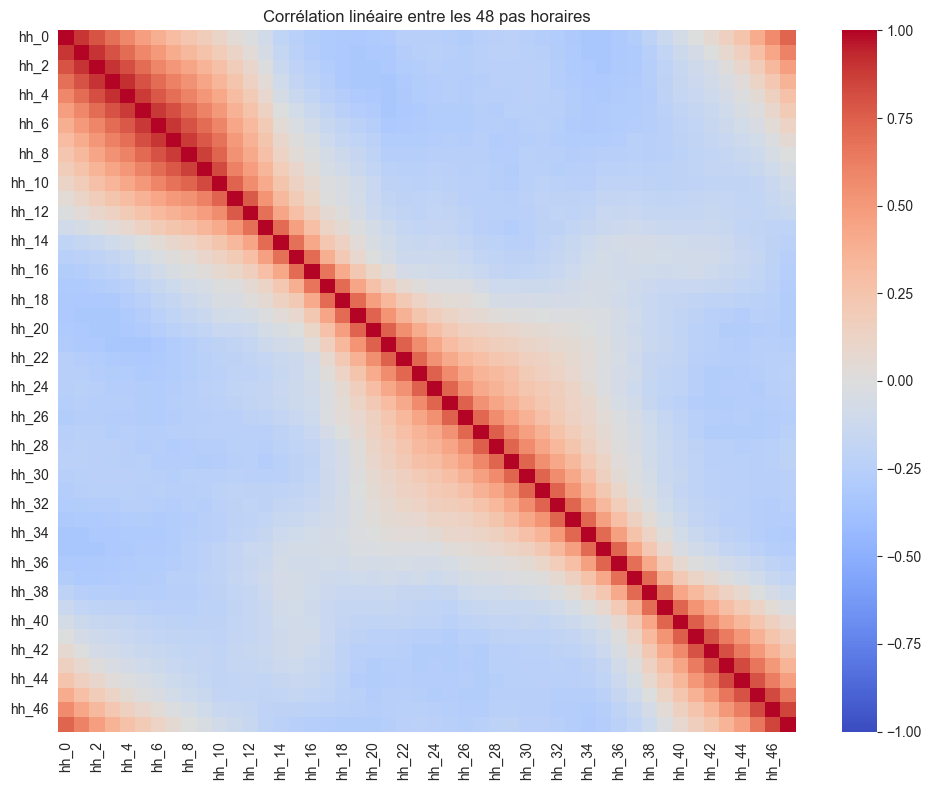

In [84]:
# On reconstruit un DataFrame à partir de X_row_scaled pour utiliser .corr() facilement
df_scaled = pd.DataFrame(X_row_scaled, columns=hh_cols)

# .corr() calcule la corrélation linéaire (Pearson) entre chaque paire de colonnes
correlation_matrix = df_scaled.corr()

plt.figure(figsize=(10, 8))
# sns.heatmap : affiche la matrice sous forme de carte de chaleur
# cmap="coolwarm" : rouge = corrélation positive forte, bleu = corrélation négative forte
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Corrélation linéaire entre les 48 pas horaires")
plt.tight_layout()
plt.show()

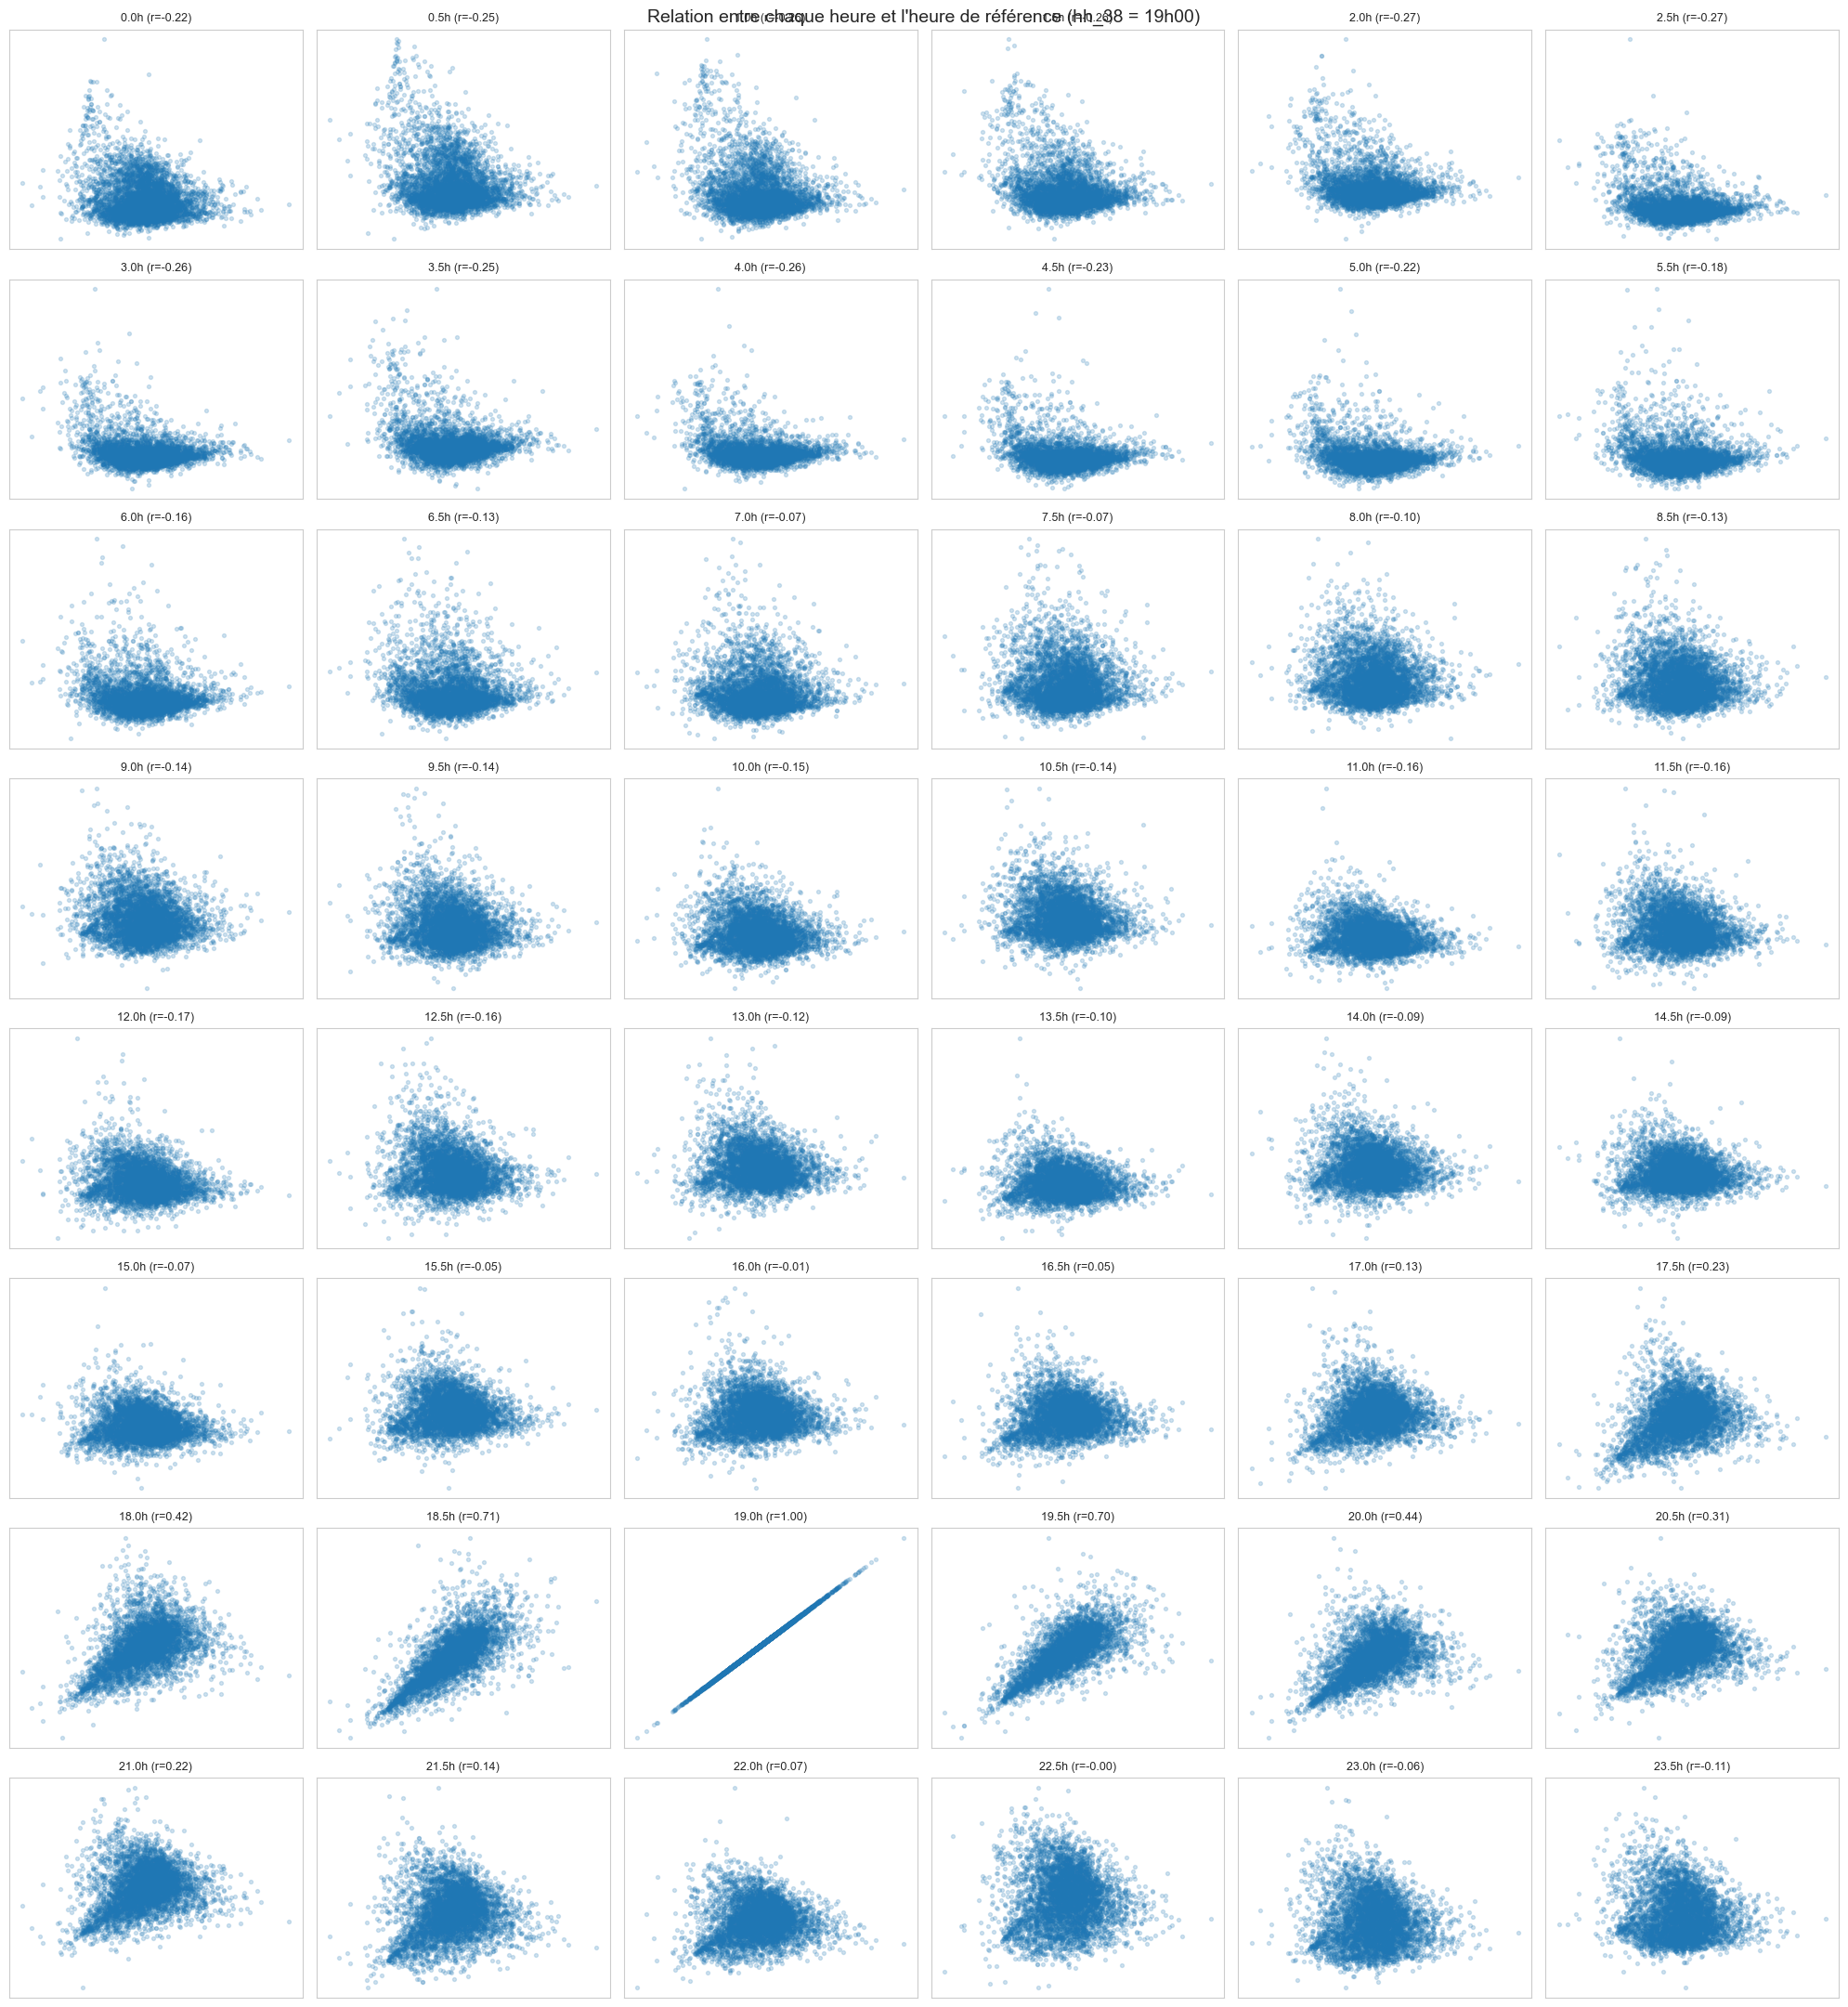

In [85]:
# On choisit une heure de référence pour comparer toutes les autres heures à elle
# hh_38 = 19h00 (le pic du soir, souvent la variable la plus "informative")
HEURE_REFERENCE = "hh_38"

# fig, axes : on crée une grille de 8 lignes x 6 colonnes = 48 sous-graphiques (1 par heure)
fig, axes = plt.subplots(8, 6, figsize=(20, 22))

# .flatten() transforme la grille 2D d'axes (8x6) en une liste 1D de 48 axes,
# plus simple à parcourir avec une seule boucle
axes = axes.flatten()

for i, col in enumerate(hh_cols):
    ax = axes[i]

    # Nuage de points : cette heure (col) vs l'heure de référence
    ax.scatter(df_scaled[HEURE_REFERENCE], df_scaled[col], alpha=0.2, s=8)

    # .corr() entre deux colonnes calcule directement leur coefficient de corrélation (Pearson)
    correlation = df_scaled[HEURE_REFERENCE].corr(df_scaled[col])

    # Titre du sous-graphique : le nom de l'heure + son coefficient de corrélation
    heure_du_jour = i / 2  # conversion de l'indice hh_i en heure réelle
    ax.set_title(f"{heure_du_jour:.1f}h (r={correlation:.2f})", fontsize=9)

    # On enlève les graduations pour ne pas surcharger visuellement (on a 48 graphiques)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(f"Relation entre chaque heure et l'heure de référence ({HEURE_REFERENCE} = 19h00)", fontsize=14)
plt.tight_layout()
plt.show()

In [86]:
mask_std_valide = row_std.flatten() != 0

print(f"Foyers exclus (courbe plate, std=0) : {(~mask_std_valide).sum()}")
print(f"Foyers conservés : {mask_std_valide.sum()}")

X_filtre = X[mask_std_valide]

row_mean_filtre = X_filtre.mean(axis=1, keepdims=True)
row_std_filtre = X_filtre.std(axis=1, keepdims=True)
X_row_scaled = (X_filtre - row_mean_filtre) / row_std_filtre

print("NaN restants :", np.isnan(X_row_scaled).sum())

mean_curves = mean_curves[mask_std_valide]
print("Nouvelle shape mean_curves:", mean_curves.shape)

Foyers exclus (courbe plate, std=0) : 3
Foyers conservés : 4705
NaN restants : 0
Nouvelle shape mean_curves: (4705, 48)


In [87]:
# PCA(n_components=2) : on demande de réduire à 2 dimensions
# (les 2 axes qui capturent le plus de variance dans les données)
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_row_scaled)

print("Shape après PCA:", X_pca.shape)

print("Variance expliquée par PC1:", pca.explained_variance_ratio_[0])
print("Variance expliquée par PC2:", pca.explained_variance_ratio_[1])
print("Variance totale expliquée (PC1+PC2):", pca.explained_variance_ratio_.sum())

Shape après PCA: (4705, 2)
Variance expliquée par PC1: 0.21621629201246798
Variance expliquée par PC2: 0.1480975968423953
Variance totale expliquée (PC1+PC2): 0.36431388885486327


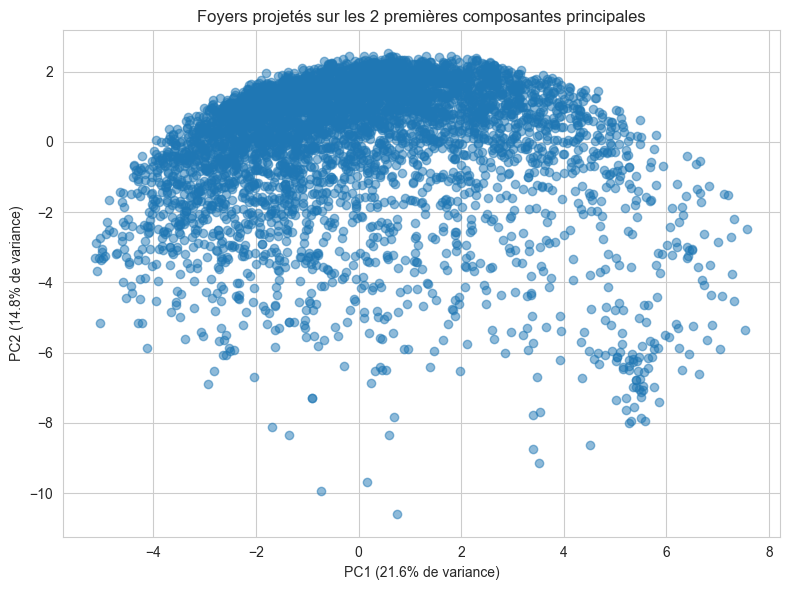

In [88]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% de variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% de variance)")
plt.title("Foyers projetés sur les 2 premières composantes principales")
plt.tight_layout()
plt.show()

In [89]:
K_RANGE = range(2, 8)

inerties = []
silhouettes = []
davies_bouldin_scores = []

for k in K_RANGE:
    
    km = KMeans(n_clusters=k, random_state=42, n_init=10)

    labels = km.fit_predict(X_row_scaled)

    inerties.append(km.inertia_)

    silhouettes.append(silhouette_score(X_row_scaled, labels))

    davies_bouldin_scores.append(davies_bouldin_score(X_row_scaled, labels))

    print(f"K={k} | inertie={inerties[-1]:.2f} | silhouette={silhouettes[-1]:.3f} | davies-bouldin={davies_bouldin_scores[-1]:.3f}")

K=2 | inertie=102857.10 | silhouette=0.143 | davies-bouldin=2.288
K=3 | inertie=93124.65 | silhouette=0.139 | davies-bouldin=2.054
K=4 | inertie=87008.14 | silhouette=0.128 | davies-bouldin=2.113
K=5 | inertie=82097.41 | silhouette=0.098 | davies-bouldin=2.065
K=6 | inertie=78945.71 | silhouette=0.093 | davies-bouldin=2.126
K=7 | inertie=76393.29 | silhouette=0.080 | davies-bouldin=2.118


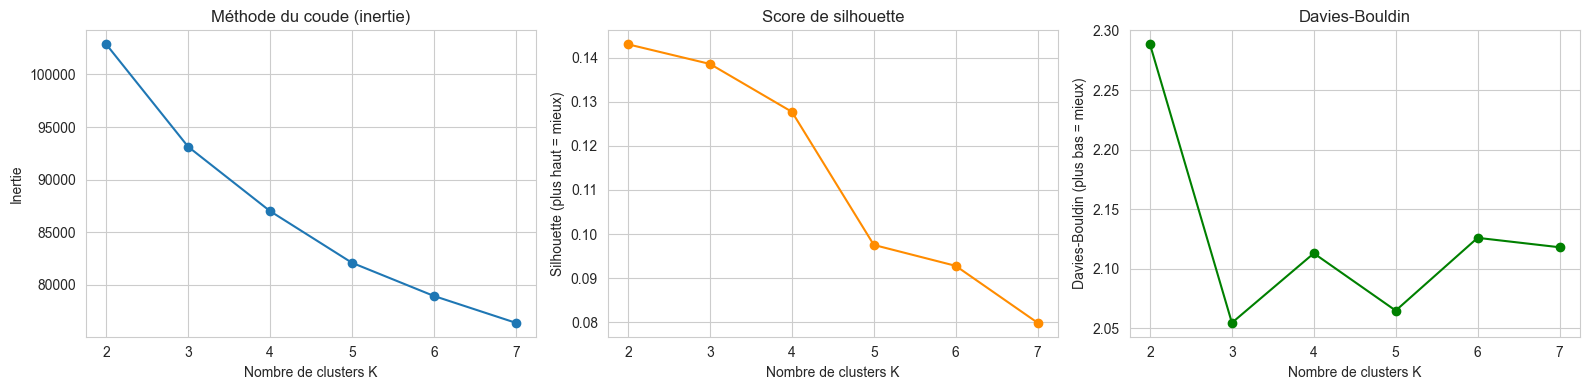

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(list(K_RANGE), inerties, marker="o")
axes[0].set_title("Méthode du coude (inertie)")
axes[0].set_xlabel("Nombre de clusters K")
axes[0].set_ylabel("Inertie")

axes[1].plot(list(K_RANGE), silhouettes, marker="o", color="darkorange")
axes[1].set_title("Score de silhouette")
axes[1].set_xlabel("Nombre de clusters K")
axes[1].set_ylabel("Silhouette (plus haut = mieux)")

axes[2].plot(list(K_RANGE), davies_bouldin_scores, marker="o", color="green")
axes[2].set_title("Davies-Bouldin")
axes[2].set_xlabel("Nombre de clusters K")
axes[2].set_ylabel("Davies-Bouldin (plus bas = mieux)")

plt.tight_layout()
plt.show()

On retient **K=3**, meilleur compromis entre les trois indicateurs : Davies-Bouldin y est optimal (2.06, ex-aequo avec K=5), la silhouette y reste proche de son maximum (0.135 vs 0.14 à K=2), et ce nombre de clusters reste interprétable et présentable comme typologie de profils de consommation.

In [ ]:
K_FINAL = 3
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)

labels_kmeans = km_final.fit_predict(X_row_scaled)

print("Répartition des foyers par cluster :")
print(pd.Series(labels_kmeans).value_counts().sort_index())



Répartition des foyers par cluster :
0     342
1    2217
2    2146
Name: count, dtype: int64


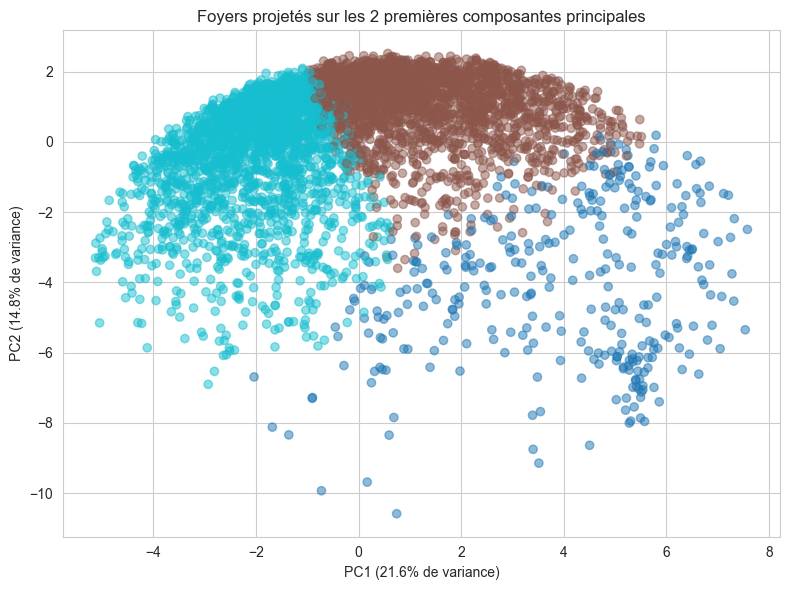

In [92]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap="tab10", alpha=0.5)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% de variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% de variance)")
plt.title("Foyers projetés sur les 2 premières composantes principales")
plt.tight_layout()
plt.show()
